In [4]:
import pandas as pd
cust_info = pd.read_csv("../data/cleaned_churn.csv")
cust_info.head()
cust_info.shape

(7043, 20)

In [5]:
cust_info.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

### Converting all data types to binary

In [6]:
cust_info = pd.read_csv('../data/cleaned_churn.csv')

from sklearn.preprocessing import LabelEncoder

binary_cols = ['gender','Partner','Dependents','PhoneService','MultipleLines',
               'OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport',
               'StreamingTV','StreamingMovies','PaperlessBilling']

le = LabelEncoder()
for col in binary_cols:
    cust_info[col] = le.fit_transform(cust_info[col].astype(str))

cust_info = pd.get_dummies(cust_info, columns=['Contract','InternetService','PaymentMethod'])

print(cust_info.dtypes)


gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
Contract_Month-to-month                       bool
Contract_One year                             bool
Contract_Two year              

### Splitting the data into training and testing data

In [7]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = cust_info.drop('Churn', axis=1)
y = cust_info['Churn']

np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

X_train_sc,X_test_sc

(array([[ 0.99433624, -0.44177295, -0.96923413, ..., -0.52380561,
          1.40690298, -0.54384572],
        [ 0.99433624, -0.44177295,  1.03174245, ..., -0.52380561,
         -0.71078107,  1.83875676],
        [ 0.99433624, -0.44177295,  1.03174245, ..., -0.52380561,
         -0.71078107,  1.83875676],
        ...,
        [-1.00569602,  2.2636062 , -0.96923413, ..., -0.52380561,
         -0.71078107,  1.83875676],
        [-1.00569602, -0.44177295,  1.03174245, ...,  1.90910518,
         -0.71078107, -0.54384572],
        [ 0.99433624, -0.44177295, -0.96923413, ..., -0.52380561,
         -0.71078107,  1.83875676]], shape=(5634, 26)),
 array([[ 0.99433624, -0.44177295,  1.03174245, ...,  1.90910518,
         -0.71078107, -0.54384572],
        [-1.00569602,  2.2636062 , -0.96923413, ...,  1.90910518,
         -0.71078107, -0.54384572],
        [-1.00569602, -0.44177295,  1.03174245, ...,  1.90910518,
         -0.71078107, -0.54384572],
        ...,
        [ 0.99433624, -0.44177295, -

### Instanting, fitting and testing the models

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

np.random.seed(42)
models={
    "RFC" : RandomForestClassifier(),
    "LR" : LogisticRegression(),
    "KNC" : KNeighborsClassifier(),
    "SVmodel" : SVC(probability=True),
    "Xgb" : XGBClassifier() 
}

results=[]

for name,model in models.items():
    model.fit(X_train_sc,y_train)
    y_preds = model.predict(X_test_sc)
    y_probs = model.predict_proba(X_test_sc)[:, 1]

    results.append({
        "Model" : name,
        "Accuracy" : accuracy_score(y_test,y_preds),
        "AUC-ROC" : roc_auc_score(y_test, y_probs)
    })

results_df = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
results_df

C:\Users\acer\AppData\Roaming\Python\Python314\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Model,Accuracy,AUC-ROC
0,LR,0.806246,0.841807
1,RFC,0.786373,0.823524
2,Xgb,0.784244,0.819626
3,SVmodel,0.786373,0.798642
4,KNC,0.754436,0.773365


##### The best performing model out of all is Logistic Regression. It means the churn patterns in this data are largely linear (simpler relationships), so a simple model handles it well.

In [30]:
LR = LogisticRegression()
params = LR.get_params()
params

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': 0.0,
 'max_iter': 100,
 'n_jobs': None,
 'penalty': 'deprecated',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

### Tuning the model

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

params = {
    'C'          : [0.01, 0.1, 1, 10, 100],
    'penalty'    : ['l1', 'l2'],
    'solver'     : ['liblinear', 'saga'],
    'max_iter'   : [100, 500, 1000]
}

grid = GridSearchCV(
    LogisticRegression(),
    params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train_sc, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV AUC-ROC:", grid.best_score_)

C:\Users\acer\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\acer\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best parameters: {'C': 10, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV AUC-ROC: 0.8459277011027593


GridSearchCV Results — Logistic Regression Tuning

Best parameters found: C=10, penalty='l1', solver='liblinear', max_iter=1000
* C=10 indicates weak regularization performed best, suggesting the dataset is clean and well-structured enough for the model to fit it more closely without overfitting.
* penalty='l1' (Lasso) won over l2, meaning some encoded features had little to no predictive value for churn — l1 automatically zeroed these out, producing a leaner, more interpretable model.
* solver='liblinear' was the optimal solver, consistent with expectations for a small binary classification dataset (~7,000 rows).
* max_iter=1000 confirms the model required full iterations to converge — lower values like 100 or 500 would have produced premature convergence warnings and suboptimal weights.
* Best cross-validated AUC-ROC: 0.8459 — an improvement over the baseline Logistic Regression score of 0.8418, confirming that hyperparameter tuning produced a meaningful, if modest, performance gain. The model was evaluated using 5-fold cross-validation on the training set, ensuring the score is a reliable estimate of generalization performance rather than a result of a single lucky split.

### Overall Evaluations

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay

best_lr = grid.best_estimator_

y_pred = best_lr.predict(X_test_sc)
y_prob = best_lr.predict_proba(X_test_sc)[:, 1]

print("Tuned LR Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Tuned LR AUC-ROC  :", round(roc_auc_score(y_test, y_prob), 4))
print()
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Tuned LR Accuracy : 0.8034
Tuned LR AUC-ROC  : 0.8409

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



### Confusion matrix

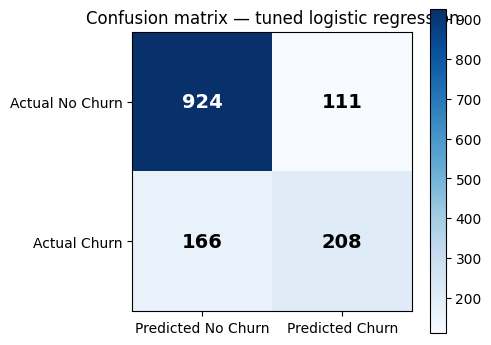

In [36]:
%matplotlib inline
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks([0, 1]); ax.set_xticklabels(['Predicted No Churn', 'Predicted Churn'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Actual No Churn', 'Actual Churn'])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', 
                color='white' if cm[i, j] > cm.max()/2 else 'black',
                fontsize=14, fontweight='bold')

fig.colorbar(im)
plt.title('Confusion matrix — tuned logistic regression')
plt.tight_layout()
plt.show()

### ROC Curve

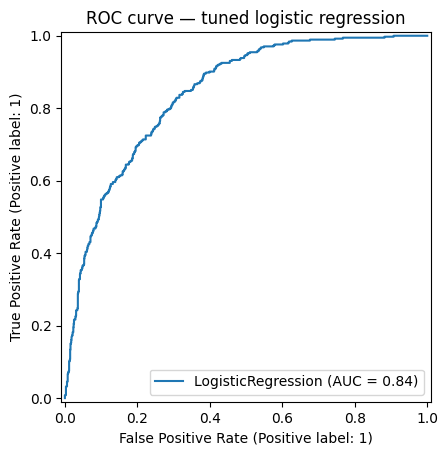

In [37]:
RocCurveDisplay.from_estimator(best_lr, X_test_sc, y_test)
plt.title('ROC curve — tuned logistic regression')
plt.show()

In [40]:
import shap

explainer = shap.LinearExplainer(best_lr, X_train_sc)
shap_values = explainer.shap_values(X_test_sc)

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.
